## Pemanggilan Library

In [2]:
import geopandas as gpd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import folium

## Persiapan Data

### Memanggil Dataset

In [3]:
# Membaca file GeoJSON
gdf = gpd.read_file(r"D:/Bootcamp MAPID - WebGIS Development/MAPID 4/demografi_kota_surabaya.geojson") 
from IPython.display import display
display(gdf.head())

Cannot find header.dxf (GDAL_DATA is not defined)


,fid,ID_PROV,PROVINSI,ID_KABKOT,KABKOT,ID_KEC,KECAMATAN,ID_DESA,DESA,JUMLAH PENDUDUK,...,MENGURUS RUMAH TANGGA,PERDAGANGAN,PERAWAT,NELAYAN,PELAJAR DAN MAHASISWA,GURU,WIRASWASTA,PENGACARA,PEKERJAAN LAINNYA,geometry
0,81107,35,JAWA TIMUR,35.78,KOTA SURABAYA,35.78.19,BENOWO,35.78.19.1005,ROMOKALISARI,3299,...,530,9,2,1,573,30,159,0,0,"MULTIPOLYGON Z (((112.65612 -7.19378 0.00000, ..."
1,80983,35,JAWA TIMUR,35.78,KOTA SURABAYA,35.78.05,TEGALSARI,35.78.05.1005,WONOREJO,26156,...,5040,52,10,0,6481,117,860,2,0,"MULTIPOLYGON Z (((112.73505 -7.26808 0.00000, ..."
2,80982,35,JAWA TIMUR,35.78,KOTA SURABAYA,35.78.03,RUNGKUT,35.78.03.1005,WONOREJO,20255,...,2735,15,30,5,5103,174,1212,3,0,"MULTIPOLYGON Z (((112.84346 -7.30556 0.00000, ..."
3,80966,35,JAWA TIMUR,35.78,KOTA SURABAYA,35.78.16,SEMAMPIR,35.78.16.1003,WONOKUSUMO,68777,...,13898,29,36,1,13991,335,4155,2,0,"MULTIPOLYGON Z (((112.76093 -7.21297 0.00000, ..."
4,80961,35,JAWA TIMUR,35.78,KOTA SURABAYA,35.78.04,WONOKROMO,35.78.04.1001,WONOKROMO,39613,...,5925,37,39,3,8808,415,2282,1,0,"MULTIPOLYGON Z (((112.73743 -7.29975 0.00000, ..."


### Mengecek Nilai null

In [4]:
# Memeriksa apakah ada nilai null di setiap kolom
null_data = gdf.isnull().sum()
# Menampilkan kolom-kolom yang memiliki nilai null beserta jumlah null di masing-masing kolom
print(null_data.head(50))

fid                               0
ID_PROV                           0
PROVINSI                          0
ID_KABKOT                         0
KABKOT                            0
ID_KEC                            0
KECAMATAN                         0
ID_DESA                           0
DESA                              0
JUMLAH PENDUDUK                   0
JUMLAH KK                         0
LUAS WILAYAH (KM2)                0
KEPADATAN PENDUDUK                0
PERPINDAHAN PENDUDUK              0
JUMLAH MENINGGAL                  0
PERUBAHAN DATA                    0
JUMLAH WAJIB KTP                  0
JUMLAH REKAM WAJIB KTP            0
ISLAM                             0
KRISTEN                           0
KATHOLIK                          0
HINDU                             0
BUDDHA                            0
KONGHUCU                          0
KEPERCAYAAN TERHADAP TUHAN YME    0
LAKI-LAKI                         0
PEREMPUAN                         0
BELUM KAWIN                 

## Analisis Statistik Sederhana

### Statistik Deskriptif JUMLAH PENDUDUK, KEPADATAN PENDUDUK, JUMLAH KK, dan JUMLAH WAJIB KTP

In [5]:
# Statistik deskriptif untuk seluruh kolom numerik
print(gdf.describe()) #kolomnya standard
gdf.describe() #agar kolomnya lebih rapi
#Menampilkan kolom numerik tertentu
gdf[['JUMLAH PENDUDUK', 'KEPADATAN PENDUDUK', 'JUMLAH KK', 'JUMLAH WAJIB KTP' ]].describe() #agar kolomnya lebih rapih

                fid  JUMLAH PENDUDUK     JUMLAH KK  LUAS WILAYAH (KM2)  \
count    154.000000       154.000000    154.000000          154.000000   
mean   77757.461039     19347.266234   6436.785714            2.181330   
std     1801.661724     11772.577708   3790.130684            2.334688   
min    74700.000000         0.000000      0.000000            0.351702   
25%    76227.250000     11872.500000   3903.750000            0.904818   
50%    77680.500000     15991.000000   5443.500000            1.444042   
75%    79251.750000     23063.000000   7771.500000            2.733696   
max    81107.000000     68777.000000  21647.000000           20.844124   

       KEPADATAN PENDUDUK  PERPINDAHAN PENDUDUK  JUMLAH MENINGGAL  \
count          154.000000            154.000000        154.000000   
mean            57.594005             57.162338        101.136364   
std             35.045256             37.068647         67.966742   
min              0.000000              0.000000          

,JUMLAH PENDUDUK,KEPADATAN PENDUDUK,JUMLAH KK,JUMLAH WAJIB KTP
count,154.000000,154.000000,154.000000,154.000000
mean,19347.266234,57.594005,6436.785714,14445.435065
std,11772.577708,35.045256,3790.130684,8597.101428
min,0.000000,0.000000,0.000000,0.000000
25%,11872.500000,35.342710,3903.750000,8851.750000
50%,15991.000000,47.602888,5443.500000,12176.500000
75%,23063.000000,68.655206,7771.500000,17408.750000
max,68777.000000,204.739153,21647.000000,48684.000000


### Menampilkan 5 Desa Terpadat

In [30]:
# Sort by 'KEPADATAN_PENDUDUK' in descending order and select the top 5
top_5_data = gdf.sort_values(by='KEPADATAN PENDUDUK', ascending=True).head(5) 
# Display the top 5 regions and their population densities
print(top_5_data[['DESA', 'KEPADATAN PENDUDUK']])

                    DESA  KEPADATAN PENDUDUK
49           PERAK TIMUR            0.000000
48           PERAK UTARA            0.000000
0           ROMOKALISARI            9.820644
18   TAMBAK OSO WILANGUN           11.404331
139             BERINGIN           17.614051


### Menampilkan 5 Kecamatan Terpadat

In [28]:
# Sort by 'KEPADATAN_PENDUDUK' in descending order and select the top 5
top_5_data = gdf.sort_values(by='KEPADATAN PENDUDUK', ascending=True).head(5) 
#False untuk terkecil
# Display the top 5 regions and their population densities
print(top_5_data[['KECAMATAN', 'KEPADATAN PENDUDUK']])

          KECAMATAN  KEPADATAN PENDUDUK
49   PABEAN CANTIAN            0.000000
48   PABEAN CANTIAN            0.000000
0            BENOWO            9.820644
18           BENOWO           11.404331
139      SAMBIKEREP           17.614051


## Analisis Geometri

### Plotting Data

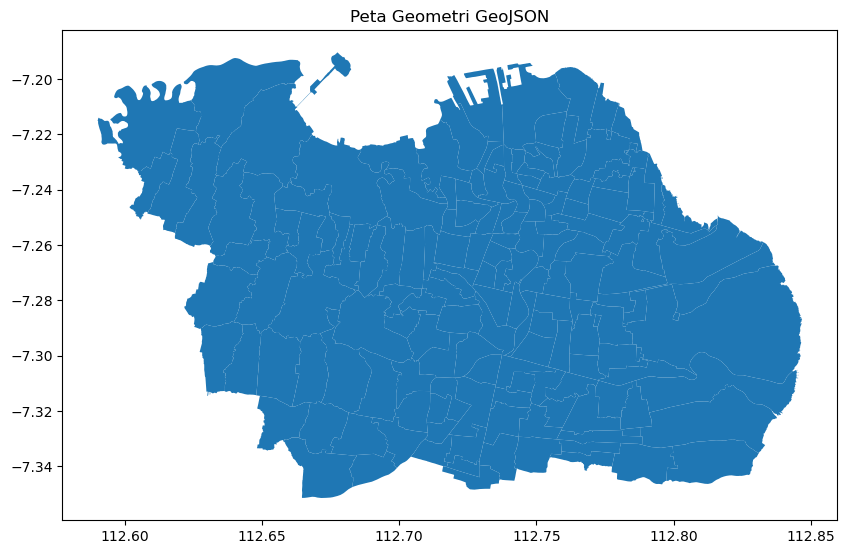

In [8]:
# ploting data geojson dalam peta
gdf.plot(figsize=(10, 10))
plt.title("Peta Geometri GeoJSON")
plt.show()

### Penentuan Centroid

In [9]:
gdf['centroid'] = gdf.geometry.centroid
print(gdf[['DESA', 'centroid']].head(50))  # Menampilkan titik pusat geometri

                    DESA                    centroid
0           ROMOKALISARI  POINT (112.63980 -7.20502)
1               WONOREJO  POINT (112.73174 -7.27113)
2               WONOREJO  POINT (112.81480 -7.31131)
3             WONOKUSUMO  POINT (112.75525 -7.21828)
4              WONOKROMO  POINT (112.73161 -7.30513)
5                 WIYUNG  POINT (112.69289 -7.31187)
6            WARU GUNUNG  POINT (112.67184 -7.34157)
7                  UJUNG  POINT (112.74691 -7.20942)
8       TENGGILIS MEJOYO  POINT (112.75812 -7.31994)
9           TEMBOK DUKUH  POINT (112.72105 -7.25281)
10             TEGALSARI  POINT (112.73762 -7.27075)
11           TANJUNGSARI  POINT (112.69039 -7.26668)
12                TANDES  POINT (112.68594 -7.25899)
13  TANAH KALI KEDINDING  POINT (112.77432 -7.22677)
14            TAMBAKSARI  POINT (112.75516 -7.25336)
15            TAMBAKREJO  POINT (112.75724 -7.24538)
16           TAMBAK WEDI  POINT (112.77443 -7.21186)
17        TAMBAK SARIOSO  POINT (112.67914 -7.

C:\Users\ACER\AppData\Local\Temp\ipykernel_28604\1780288490.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid


## Analisis Korelasi Variabel Demografi

                    JUMLAH PENDUDUK  KEPADATAN PENDUDUK  JUMLAH KK  \
JUMLAH PENDUDUK            1.000000            1.000000   0.996675   
KEPADATAN PENDUDUK         1.000000            1.000000   0.996675   
JUMLAH KK                  0.996675            0.996675   1.000000   
JUMLAH WAJIB KTP           0.998573            0.998573   0.998958   
PENSIUN                    0.524224            0.524224   0.538205   

                    JUMLAH WAJIB KTP   PENSIUN  
JUMLAH PENDUDUK             0.998573  0.524224  
KEPADATAN PENDUDUK          0.998573  0.524224  
JUMLAH KK                   0.998958  0.538205  
JUMLAH WAJIB KTP            1.000000  0.542039  
PENSIUN                     0.542039  1.000000  


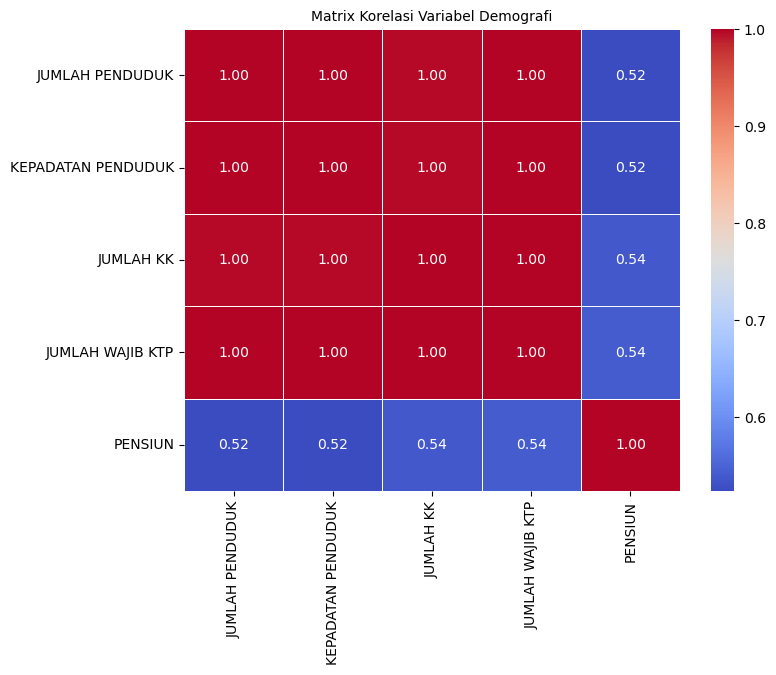

In [10]:
# Hitung korelasi tanpa matrix
correlation = gdf[['JUMLAH PENDUDUK', 'KEPADATAN PENDUDUK', 'JUMLAH KK', 'JUMLAH WAJIB KTP', 'PENSIUN']].corr()
print(correlation)
# hitung korelasi dengan plot heatmap matrix agar lebih menarik
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matrix Korelasi Variabel Demografi", fontsize=10)
plt.show()

## Distribusi Spasial Kepadatan Penduduk

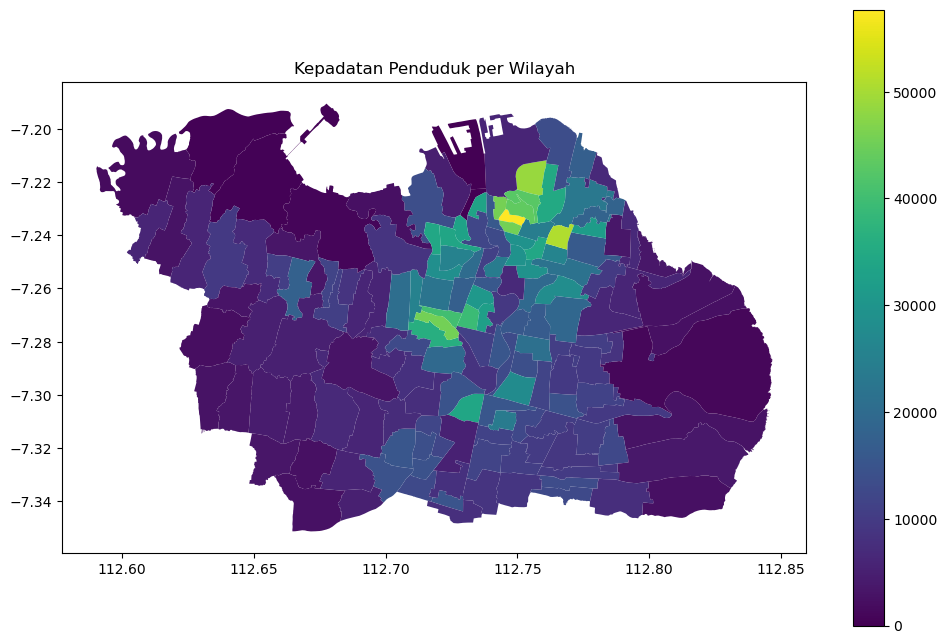

In [12]:
gdf['KEPADATAN_PENDUDUK'] = gdf['JUMLAH PENDUDUK'] / gdf['LUAS WILAYAH (KM2)']
gdf.plot(column='KEPADATAN_PENDUDUK', cmap='viridis', legend=True, figsize=(12, 8))
plt.title('Kepadatan Penduduk per Wilayah')
plt.show()

## Peta Tematik Interaktif

In [24]:
gdf = gpd.read_file(r"D:/Bootcamp MAPID - WebGIS Development/MAPID 4/demografi_kota_surabaya.geojson") 
    # Membuat peta di titik tengah GeoJSON
map_center = [gdf.geometry.centroid.y.mean(), gdf.geometry.centroid.x.mean()]
mymap = folium.Map(location=map_center, zoom_start=13)
 # Menambahkan Choropleth
folium.Choropleth(
 geo_data=gdf.to_json(),  # Data GeoJSON
 name='choropleth',  # Nama layer choropleth
 data=gdf,  # Data yang digunakan untuk coloring
 columns=['KECAMATAN', 'JUMLAH PENDUDUK'],  # Kolom yang digunakan (nama wilayah, nilai)
 key_on='feature.properties.KECAMATAN',  # Key pada geojson yang digunakan untuk menghubungkan data
 fill_color='Purples',  # Skema warna 
 fill_opacity=0.7,  # Opasitas pengisian
 legend_name='Jumlah Penduduk',  # Nama legenda
 ).add_to(mymap)
 #menambahkan outline pada peta
folium.GeoJson(gdf,popup=folium.GeoJsonPopup(fields=['KECAMATAN', 'DESA', 'JUMLAH PENDUDUK', 'KEPADATAN PENDUDUK'], labels=True, localize=True),style_function=lambda feature: {'color': 'black','weight': 2,'fillOpacity': 0}).add_to(mymap)
 # warna garis,
 # ketebalan garis
 # transparan isi, supaya cuma garisnya
mymap

C:\Users\ACER\AppData\Local\Temp\ipykernel_28604\183632480.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  map_center = [gdf.geometry.centroid.y.mean(), gdf.geometry.centroid.x.mean()]


# Summary
## 3 Kecamatan dengan jumlah penduduk tertinggi dan terendah
### Tertinggi
SEMAMPIR:(204.739153)
KENJERAN:(187.881223)
KENJERAN:(186.571407)
### Terendah
BENOWO            9.820644
BENOWO            11.404331
SAMBIKEREP        17.614051

---------------------------------------------
Apabila dataset kelompok bernilai 0 dimasukkan, maka:

49   PABEAN CANTIAN            0.000000
48   PABEAN CANTIAN            0.000000

## 3 Desa dengan kepadatan penduduk tertinggi dan terendah
### Tertinggi
WONOKUSUMO:(204.739153)
SIDOTOPO WETAN:(187.881223)
TANAH KALI KEDINDING:(186.571407)
### Terendah
ROMOKALISARI:(9.820644)
TAMBAK OSO WILANGUN:(11.404331)
BERINGIN:(17.614051)

---------------------------------------
Apabila dataset kelompok bernilai 0 dimasukkan, maka:

49  PERAK TIMUR            0.000000
48  PERAK UTARA            0.000000

## Analisis korelasi antar variabel demografi
Dari keempat variabel, variabel yang tidak memiliki korelasi yang baik hanyalah variabel "PENSIUN". Karena keempat variabel lain memiliki nilai matriks korelasi yang mendekati 1. 